In [ ]:
!pip install langgraph

# Basic graph

{'message': 'hello -> greeted by node!'}


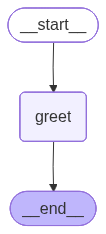

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


class State(TypedDict):
    message: str

def greet(state: State) -> dict:
    return {"message": state["message"] + " -> greeted by node!"}

builder = StateGraph(State)
builder.add_node("greet", greet)
builder.add_edge(START, "greet")
builder.add_edge("greet", END)

graph = builder.compile()
result = graph.invoke({"message": "hello"})
print(result)
display(
    Image(graph.get_graph().draw_mermaid_png())
)

# chaining multiple nodes

Running graph...
  [add_item]    reading: item=Notebook
  [compute_tax] reading: price=100
  [compute_total] reading: price=100, tax=18
Final state: {'item': 'Notebook', 'price': 100, 'tax': 18, 'total': 118}


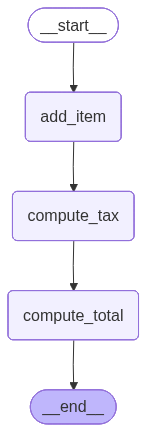

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class OrderState(TypedDict):
    item: str
    price: int
    tax: int
    total: int

def add_item(state: OrderState) -> dict:
    print(f"  [add_item]    reading: item={state['item']}")
    return {"price": 100}

def compute_tax(state: OrderState) -> dict:
    print(f"  [compute_tax] reading: price={state['price']}")
    tax = int(state["price"] * 0.18)
    return {"tax": tax}

def compute_total(state: OrderState) -> dict:
    print(f"  [compute_total] reading: price={state['price']}, tax={state['tax']}")
    return {"total": state["price"] + state["tax"]}

builder = StateGraph(OrderState)
builder.add_node("add_item", add_item)
builder.add_node("compute_tax", compute_tax)
builder.add_node("compute_total", compute_total)

builder.add_edge(START, "add_item")
builder.add_edge("add_item", "compute_tax")
builder.add_edge("compute_tax", "compute_total")
builder.add_edge("compute_total", END)

graph = builder.compile()
print("Running graph...")
result = graph.invoke({"item": "Notebook", "price": 0, "tax": 0, "total": 0})
print("Final state:", result)
display(
    Image(graph.get_graph().draw_mermaid_png())
)

# state reducers

Accumulated log: ['step_a ran', 'step_b ran', 'step_c ran']


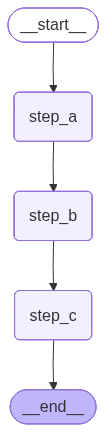

In [5]:
from typing_extensions import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class LogState(TypedDict):
    steps: Annotated[list[str], add]   # <- the reducer: HOW to combine old + new

def step_a(state: LogState) -> dict:
    return {"steps": ["step_a ran"]}   # this gets ADDED to the list, not replacing it

def step_b(state: LogState) -> dict:
    return {"steps": ["step_b ran"]}

def step_c(state: LogState) -> dict:
    return {"steps": ["step_c ran"]}

builder = StateGraph(LogState)
builder.add_node("step_a", step_a)
builder.add_node("step_b", step_b)
builder.add_node("step_c", step_c)
builder.add_edge(START, "step_a")
builder.add_edge("step_a", "step_b")
builder.add_edge("step_b", "step_c")
builder.add_edge("step_c", END)

graph = builder.compile()
result = graph.invoke({"steps": []})
print("Accumulated log:", result["steps"])
display(
    Image(graph.get_graph().draw_mermaid_png())
)

# conditional edges


Student scored 72:
  [check_score] score=72
 -> {'score': 72, 'result': 'PASSED'}

Student scored 25:
  [check_score] score=25
 -> {'score': 25, 'result': 'FAILED - needs re-exam'}


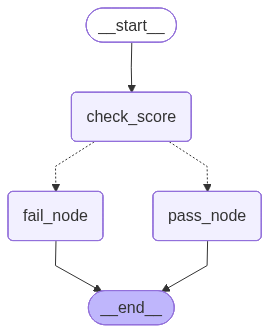

In [ ]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class ExamState(TypedDict):
    score: int
    result: str

def check_score(state: ExamState) -> dict:
    print(f"  [check_score] score={state['score']}")
    return {}

def route_by_score(state: ExamState) -> str:
    if state["score"] >= 40:
        return "pa"
    else:
        return "fn"

def pass_node(state: ExamState) -> dict:
    return {"result": "PASSED"}

def fail_node(state: ExamState) -> dict:
    return {"result": "FAILED - needs re-exam"}

builder = StateGraph(ExamState)
builder.add_node("check_score", check_score)
builder.add_node("pass_node", pass_node)
builder.add_node("fail_node", fail_node)

builder.add_edge(START, "check_score")
builder.add_conditional_edges(
    "check_score", #this is the node you are currently executing
    route_by_score, # this is the router that decides where to go
    {"pa": "pass_node", "fn": "fail_node"} # mapping so you can return
    #arbritrary naming convention
)
builder.add_edge("pass_node", END)
builder.add_edge("fail_node", END)

graph = builder.compile()
for s in [72, 25]:
    print(f"\nStudent scored {s}:")
    print(" ->", graph.invoke({"score": s, "result": ""}))


display(
    Image(graph.get_graph().draw_mermaid_png())
)

# cycles in langgraph

In [4]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
import random
from IPython.display import Image, display

class GuessState(TypedDict):
    target: int
    guess: int
    attempts: int

def make_guess(state: GuessState) -> dict:
    guess = random.randint(1, 20)
    print(f"  attempt {state['attempts']+1}: guessing {guess}")
    return {"guess": guess, "attempts": state["attempts"] + 1}

def is_correct(state: GuessState) -> str:
    if state["guess"] == state["target"]:
        return "done"
    if state["attempts"] >= 10:
        return "give_up"
    return "retry"

builder = StateGraph(GuessState)
builder.add_node("make_guess", make_guess)
builder.add_edge(START, "make_guess")
builder.add_conditional_edges(
    "make_guess",
    is_correct,
    {"done": END, "give_up": END, "retry": "make_guess"}   # <- loop: points back to itself
)

graph = builder.compile()
result = graph.invoke({"target": 7, "guess": 0, "attempts": 0})
print("Final:", result)


# display(
#     Image(graph.get_graph().draw_mermaid_png())
# )

  attempt 1: guessing 15
  attempt 2: guessing 16
  attempt 3: guessing 20
  attempt 4: guessing 7
Final: {'target': 7, 'guess': 7, 'attempts': 4}


# persistance 

call 1: {'turns': 1}
call 2: {'turns': 2}
call 3: {'turns': 3}
student-2 (fresh thread): {'turns': 1}


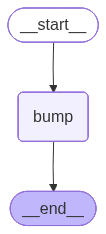

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display

class ChatState(TypedDict):
    turns: int

def bump(state: ChatState) -> dict:
    # print(f"current turn : {state.get("turns")}")
    return {"turns": state.get("turns", 0) + 1}

builder = StateGraph(ChatState)
builder.add_node("bump", bump)
builder.add_edge(START, "bump")
builder.add_edge("bump", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "student-1"}}

print("call 1:", graph.invoke({"turns": 0}, config))
print("call 2:", graph.invoke({}, config))   # empty input -> reuses saved state
print("call 3:", graph.invoke({}, config))

config2 = {"configurable": {"thread_id": "student-2"}}
print("student-2 (fresh thread):", graph.invoke({"turns": 0}, config2))

display(
    Image(graph.get_graph().draw_mermaid_png())
)

In [6]:
print("student-2 (fresh thread):", graph.invoke({}, config))

student-2 (fresh thread): {'turns': 8}


# Human in the loop

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt, Command


class State(TypedDict):
    input: str
    approved: bool
    result: str


def prepare_action(state: State):
    print(f"Preparing action for input: {state['input']}")
    return {"input": state["input"]}


def human_review(state: State):
    # Pauses execution here and surfaces this payload to whoever is running the graph
    decision = interrupt(
        {
            "question": "Approve this action?",
            "action_preview": f"About to process: {state['input']}",
        }
    )
    # Execution resumes here once Command(resume=...) is sent back in
    return {"approved": decision.get("approved", False)}


def execute_action(state: State):
    if state["approved"]:
        return {"result": f"Executed: {state['input']}"}
    return {"result": "Action rejected by human"}


def route_after_review(state: State):
    return "execute_action" if state["approved"] else END


graph = StateGraph(State)
graph.add_node("prepare_action", prepare_action)
graph.add_node("human_review", human_review)
graph.add_node("execute_action", execute_action)

graph.add_edge(START, "prepare_action")
graph.add_edge("prepare_action", "human_review")
graph.add_conditional_edges("human_review", route_after_review, {"execute_action": "execute_action", END: END})
graph.add_edge("execute_action", END)

checkpointer = InMemorySaver()
app = graph.compile(checkpointer=checkpointer)

# --- Running it ---
config = {"configurable": {"thread_id": "thread-1"}}

# First run — will pause at human_review
result = app.invoke({"input": "delete all logs older than 30 days"}, config=config)
print(result)  
# Graph is paused here. result will contain an "__interrupt__" key with the payload.

Preparing action for input: delete all logs older than 30 days
{'input': 'delete all logs older than 30 days', '__interrupt__': [Interrupt(value={'question': 'Approve this action?', 'action_preview': 'About to process: delete all logs older than 30 days'}, id='a28db4a75274fa3e8c00ae0271dd3ee5')]}


# approval

In [4]:
# ... later, after a human looks at it and approves ...
final_result = app.invoke(Command(resume={"approved": True}), config=config)
print(final_result)

{'input': 'delete all logs older than 30 days', 'approved': True, 'result': 'Executed: delete all logs older than 30 days'}


# tool calls

In [ ]:
"""
    pip install langchain-google-genai 
"""

import os
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage, HumanMessage
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from dotenv import load_dotenv


load_dotenv(dotenv_path="c:/class_proj/temp_start/.env")

# ---------------------------------------------------------------------------
# STEP 1: Define simple tools
# ---------------------------------------------------------------------------
@tool
def calculator(expression: str) -> str:
    """Evaluate a basic arithmetic expression, e.g. '12 * (3 + 4)'."""
    try:
        # Only allow safe characters — never use raw eval() on untrusted input
        allowed = set("0123456789+-*/(). ")
        if not set(expression) <= allowed:
            return "Error: expression contains disallowed characters."
        return str(eval(expression))
    except Exception as e:
        return f"Error: {e}"


@tool
def word_length(word: str) -> int:
    """Return the number of characters in a word."""
    return len(word)


tools = [calculator, word_length]

# ---------------------------------------------------------------------------
# STEP 2: Set up Gemini LLM and BIND the tools to it
# ---------------------------------------------------------------------------
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    google_api_key=os.environ.get("GOOGLE_API_KEY"),
    temperature=0,
)

# This is the key line for "tool binding" — it tells the model what
# functions it's allowed to call and their schemas (auto-derived from
# the @tool docstrings/type hints).
llm_with_tools = llm.bind_tools(tools)


# ---------------------------------------------------------------------------
# STEP 3: Define graph state
# ---------------------------------------------------------------------------
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


# ---------------------------------------------------------------------------
# STEP 4: Define nodes
# ---------------------------------------------------------------------------
def call_model(state: State) -> State:
    """LLM node: reads conversation, decides to answer or call a tool."""
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# ToolNode automatically executes whichever tool(s) the LLM asked for,
# based on the tool_calls attached to the last AI message.
tool_node = ToolNode(tools)


# ---------------------------------------------------------------------------
# STEP 5: Build the graph
# ---------------------------------------------------------------------------
graph_builder = StateGraph(State)
graph_builder.add_node("llm", call_model)
graph_builder.add_node("tools", tool_node)

graph_builder.set_entry_point("llm")

# tools_condition inspects the last message: if it has tool_calls,
# route to "tools"; otherwise route to END.
graph_builder.add_conditional_edges(
    "llm",
    tools_condition,
    {"tools": "tools", END: END},
)
# After running the tool, go back to the LLM so it can use the result
graph_builder.add_edge("tools", "llm")

graph = graph_builder.compile()


# ---------------------------------------------------------------------------
# STEP 6: Run it
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    questions = [
        "What is (24 * 17) + 9?",
        "How many letters are in 'antidisestablishmentarianism'?",
        "What's the capital of France?",  # should answer directly, no tool
    ]

    for q in questions:
        print(f"\nUSER: {q}")
        result = graph.invoke({"messages": [HumanMessage(content=q)]})
        final_message = result["messages"][-1]
        print(f"ASSISTANT: {final_message.content}")